<a href="https://colab.research.google.com/github/Prerana33a/Final-Year-Project-Prerana/blob/main/Hyper_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Intelligent Water Quality Classification for Aquaculture Management Using Machine Learning**

# **Section 1: Importing Relevent Files**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss

warnings.filterwarnings('ignore')

# **Section 2: Loading Dataset**

In [ ]:
# Load data
df = pd.read_excel('WQD.xlsx')

# **Section 3: Exploratory Data Analysis**

In [ ]:
df.head()

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2


## **Cleaning**

In [ ]:
# Clean column names (removing trailing spaces and special characters)
df.columns = [c.strip().replace('`', '').replace('  ', ' ') for c in df.columns]

# Map numerical target to descriptive labels for EDA
class_map = {0: 'Excellent', 1: 'Good', 2: 'Poor'}
df['Quality_Label'] = df['Water Quality'].map(class_map)

print("Dataset Loaded. Shape:", df.shape)

Dataset Loaded. Shape: (4300, 16)


## **Descriptive Statistical Analysis**

In [ ]:
print("\n--- Descriptive Statistics ---")
display(df.describe())


--- Descriptive Statistics ---


,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
count,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000
mean,25.695663,39.046681,5.300346,3.125079,6.375929,7.713468,93.717183,127.055476,84.871932,0.048269,0.642948,1.172749,0.016473,3805.510620,1.023256
std,9.670202,20.942726,1.832736,2.292060,2.831104,1.580282,68.949048,78.883091,75.718842,0.122886,0.903592,1.082648,0.011874,1208.547783,0.820996
min,0.194046,0.051424,0.133928,1.000621,0.001155,0.003944,25.012328,0.255805,0.018293,0.000001,0.000025,0.000128,0.000002,78.603733,0.000000
25%,19.775926,22.224140,3.978366,1.522077,5.048761,6.443019,40.422364,69.479620,23.745078,0.012750,0.010636,0.028355,0.010072,2956.020049,0.000000
50%,25.041849,30.205696,5.000754,2.236022,6.598076,7.743176,67.562607,111.063301,62.845419,0.026335,0.099908,0.975312,0.019049,3729.396476,1.000000
75%,30.277718,55.945735,6.521225,4.324578,8.241532,9.035251,132.834386,162.675648,115.596833,0.039016,1.166714,2.101317,0.019567,4555.089727,2.000000
max,84.251522,99.797743,14.970122,14.943006,14.984216,14.851195,299.913160,398.796550,399.321398,0.999300,4.989535,4.974457,0.099220,7460.415789,2.000000


## **Correlation Matrix**

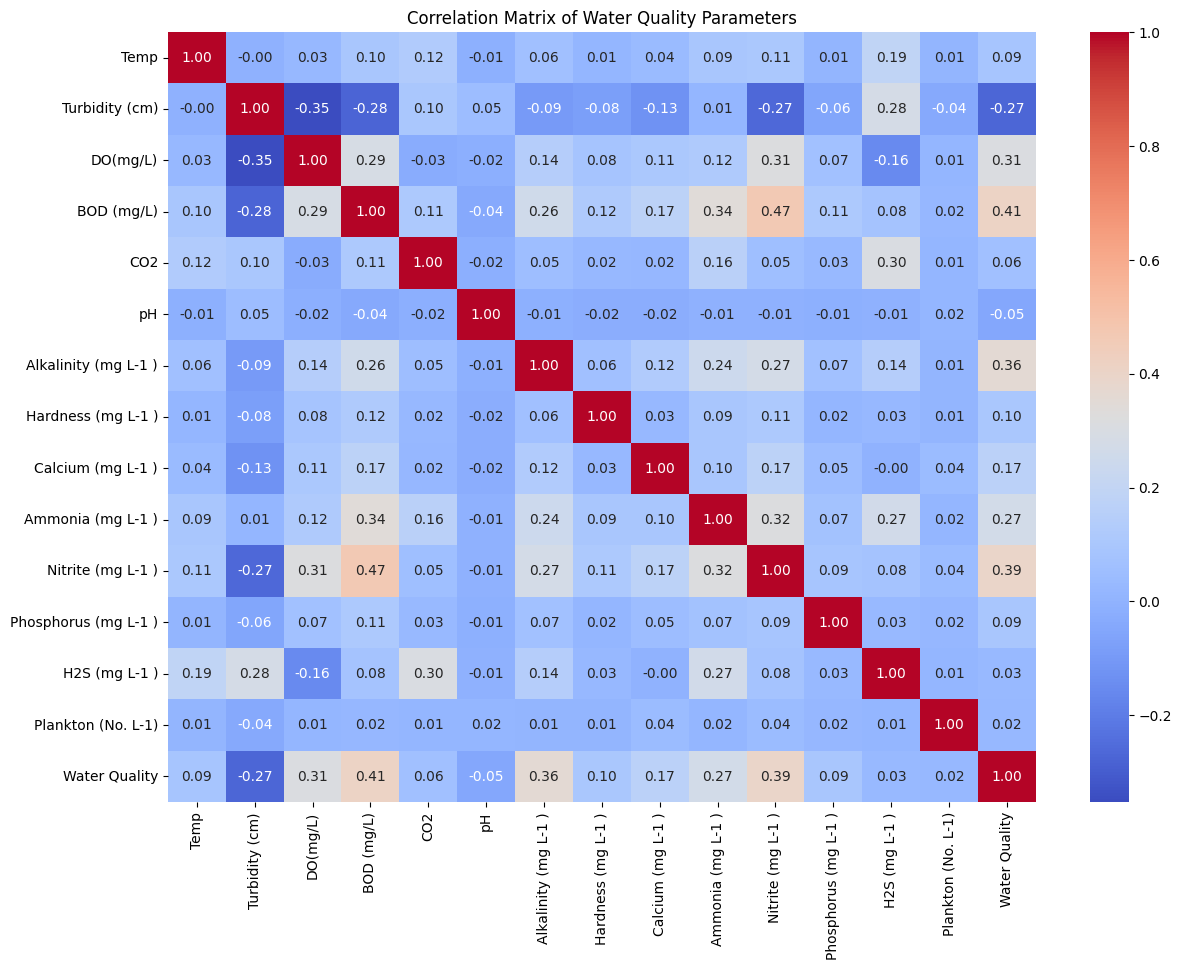

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Water Quality Parameters")
plt.show()

## **Distribution Graph**

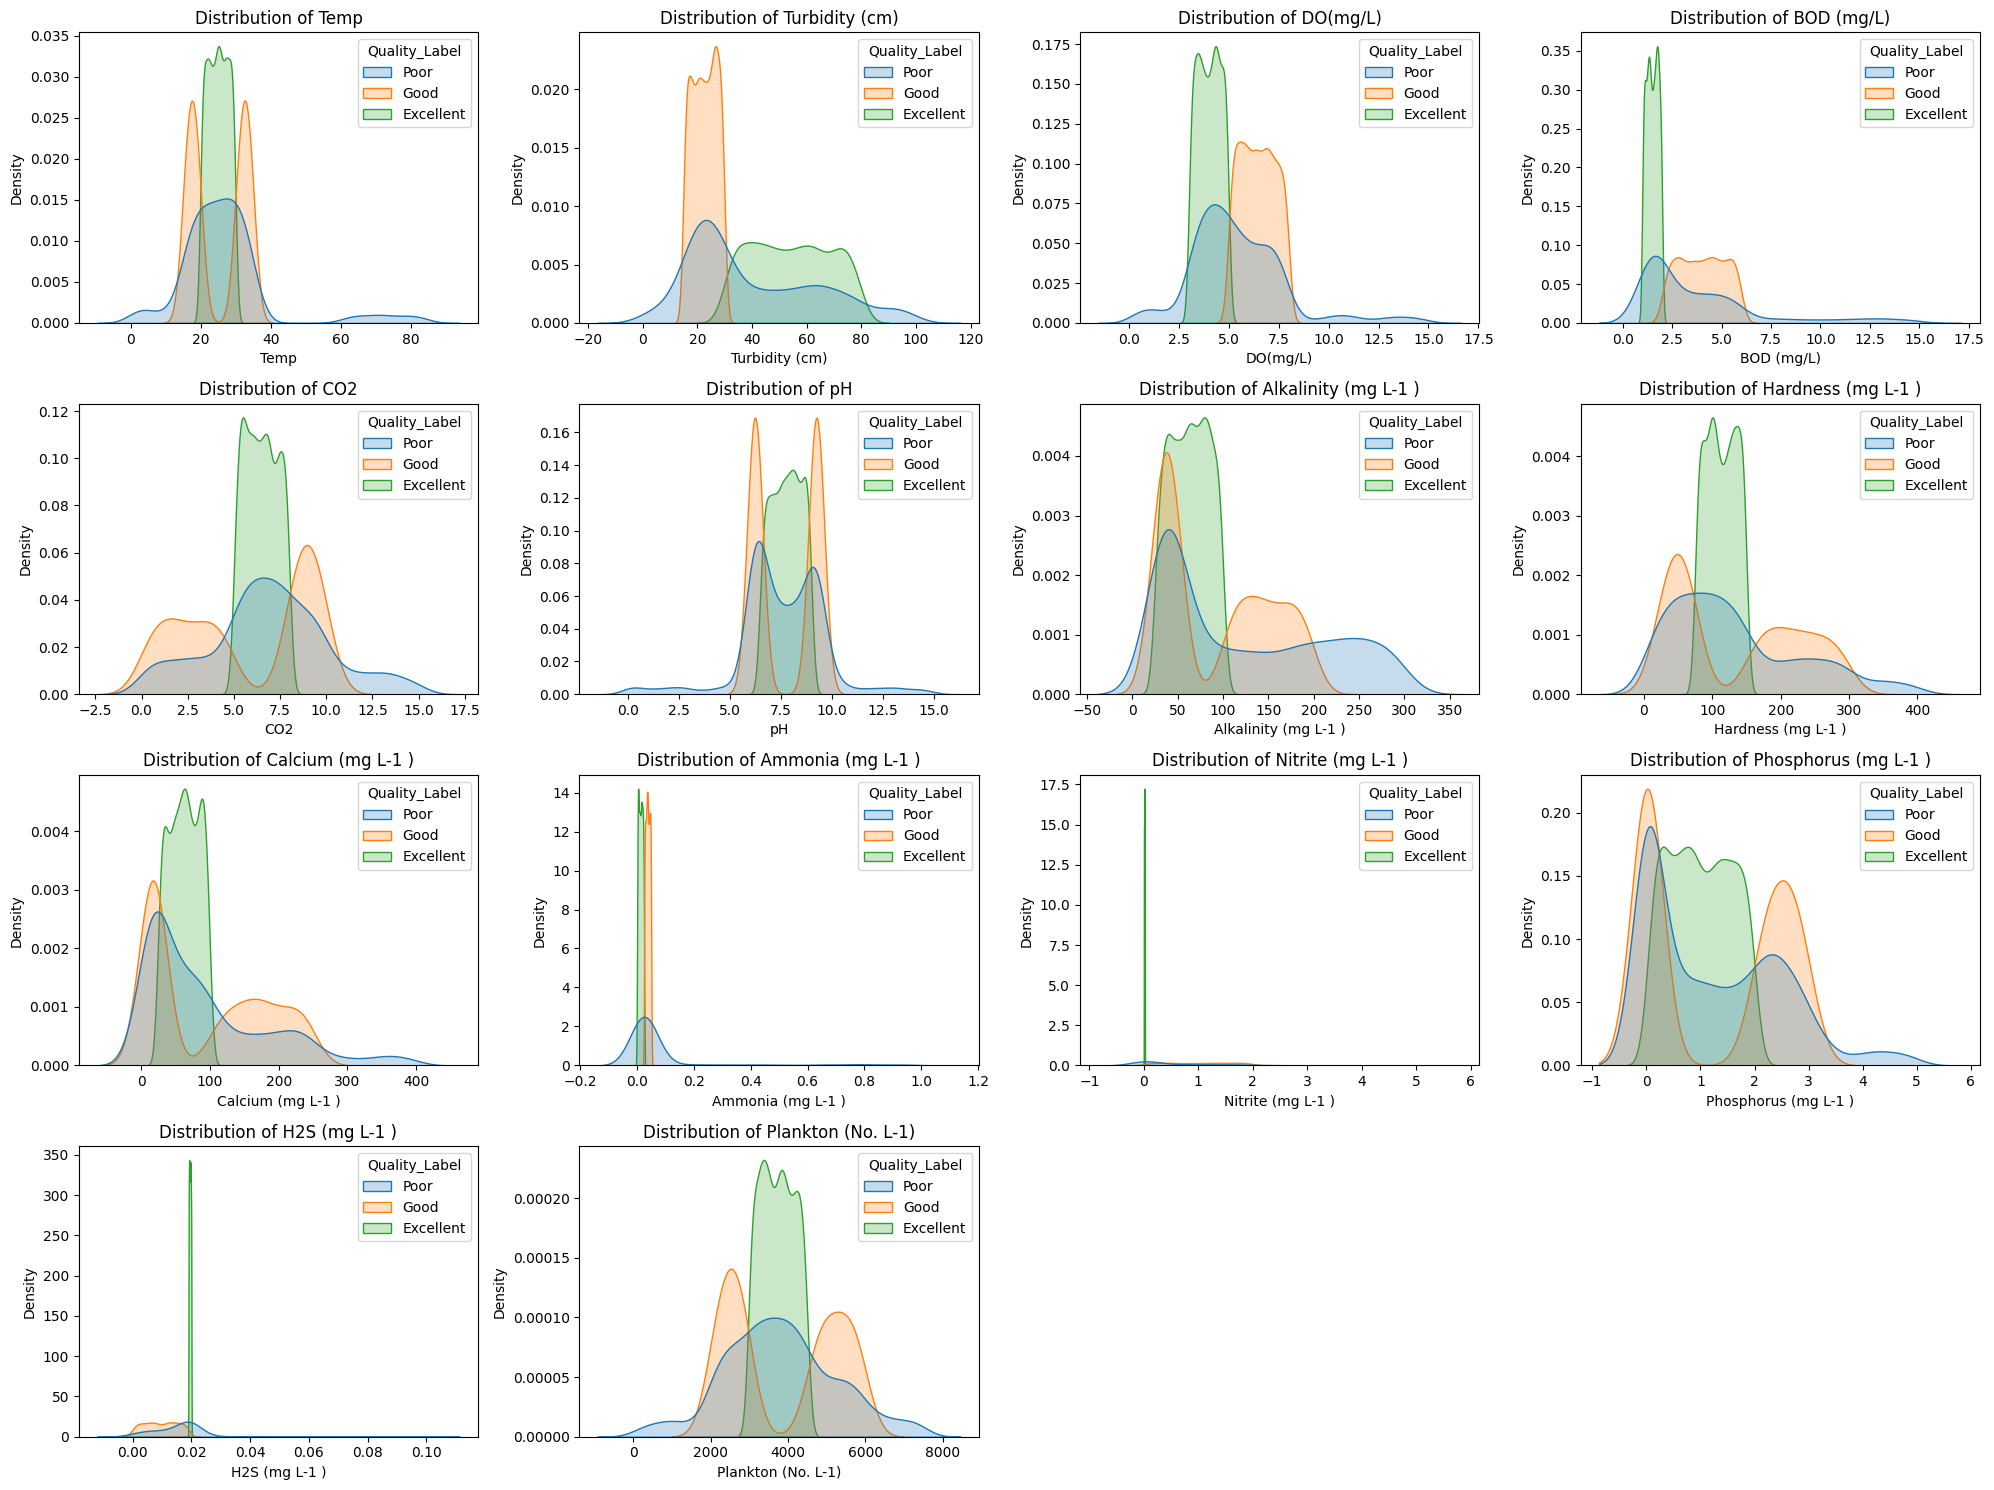

In [ ]:
features = [col for col in df.columns if col not in ['Water Quality', 'Quality_Label']]
plt.figure(figsize=(20, 15))
for i, col in enumerate(features, 1):
    plt.subplot(4, 4, i)
    sns.kdeplot(data=df, x=col, hue='Quality_Label', fill=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## **Box Plot**

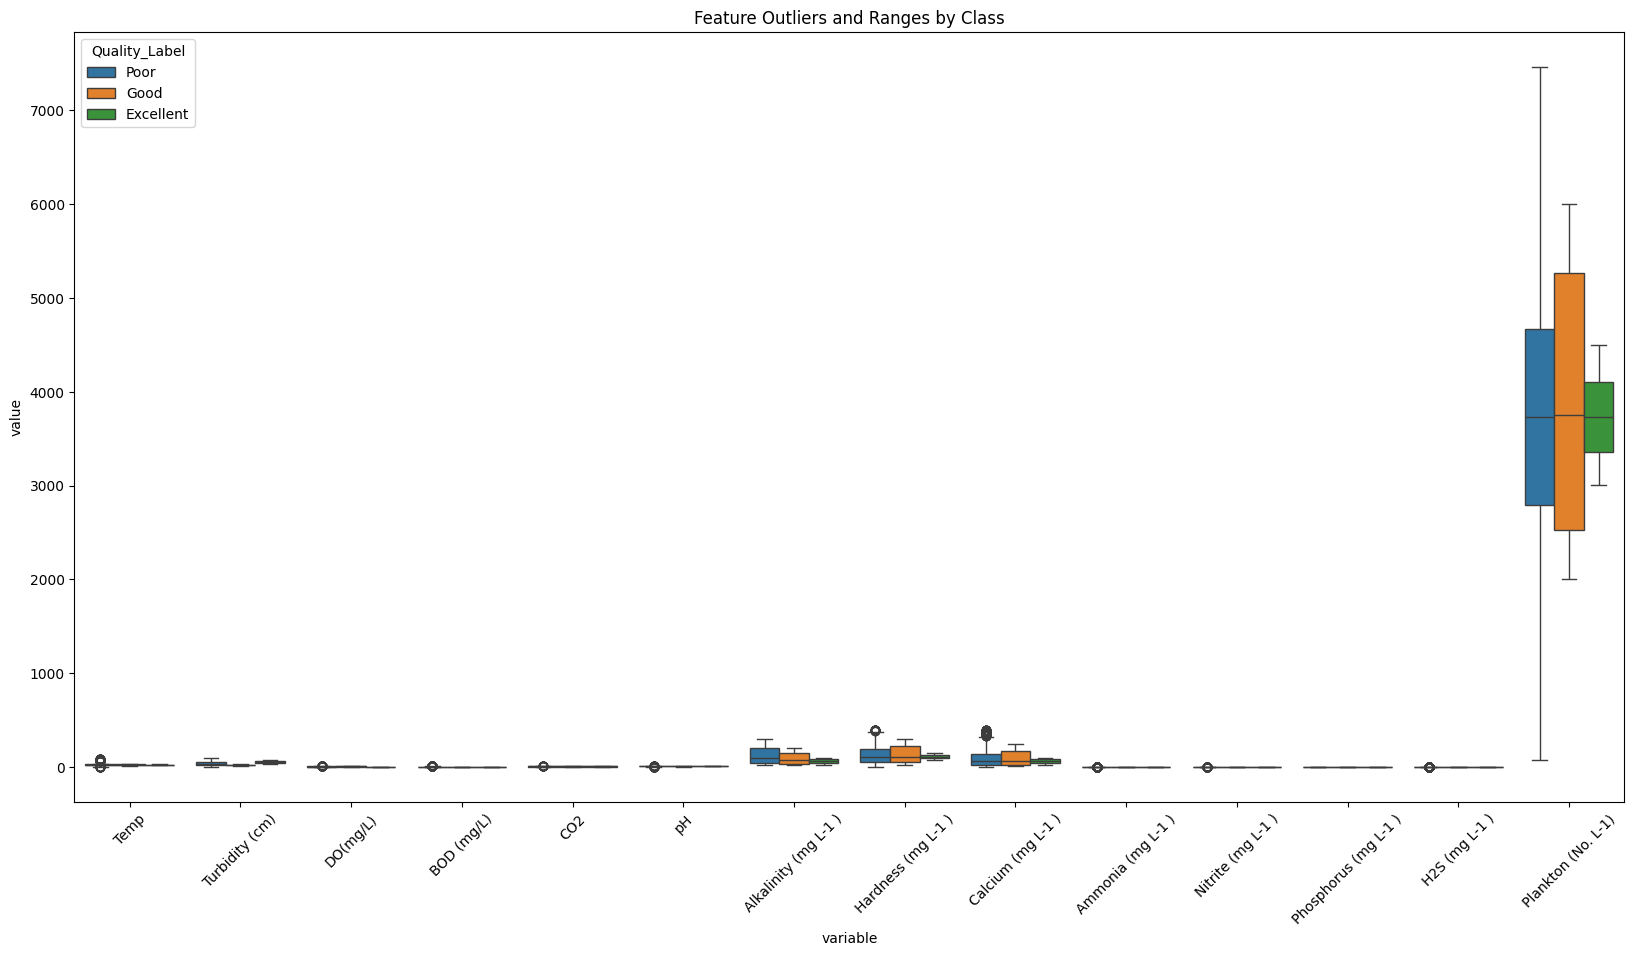

In [ ]:
plt.figure(figsize=(20, 10))
df_melted = df.melt(id_vars='Quality_Label', value_vars=features)
sns.boxplot(data=df_melted, x='variable', y='value', hue='Quality_Label')
plt.xticks(rotation=45)
plt.title("Feature Outliers and Ranges by Class")
plt.show()

## **Target Variable Distribution**

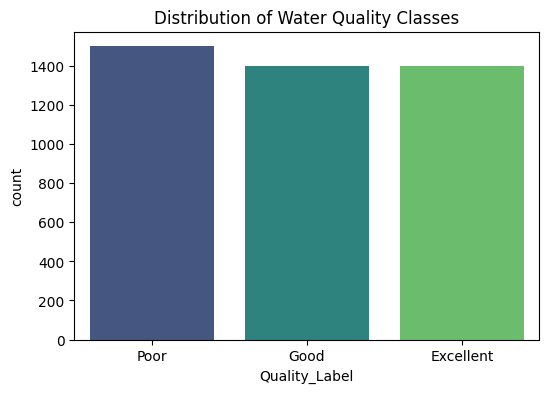

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Quality_Label', palette='viridis')
plt.title("Distribution of Water Quality Classes")
plt.show()

# **Section 4: Preprocessing**

In [ ]:
# Features and Target
X = df.drop(['Water Quality', 'Quality_Label'], axis=1)
y = df['Water Quality']

# Standardize features (essential for SVM and Gradient Based models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Data Preprocessing Complete.")

Data Preprocessing Complete.


# **Section 5: Model Training**


Model: XGBoost
Training Time:  1.3068 s
Prediction Time:0.0269 s

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       280
           1       0.99      1.00      0.99       280
           2       1.00      0.98      0.99       300

    accuracy                           0.99       860
   macro avg       0.99      0.99      0.99       860
weighted avg       0.99      0.99      0.99       860



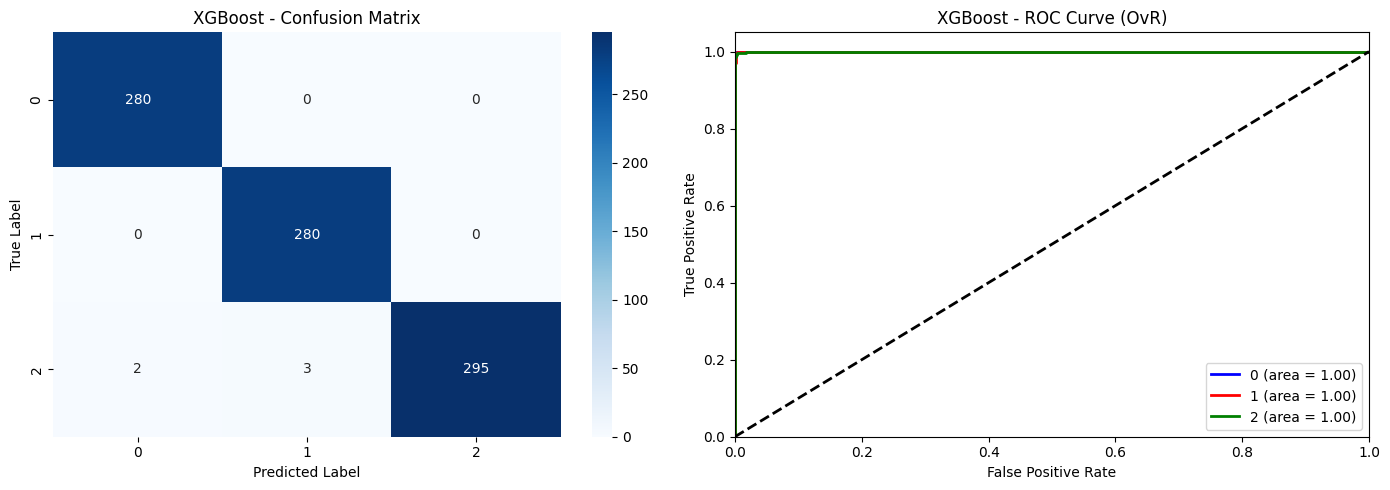


Model: Random Forest
Training Time:  4.4868 s
Prediction Time:0.0277 s

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       280
           1       0.99      1.00      0.99       280
           2       1.00      0.98      0.99       300

    accuracy                           0.99       860
   macro avg       0.99      0.99      0.99       860
weighted avg       0.99      0.99      0.99       860



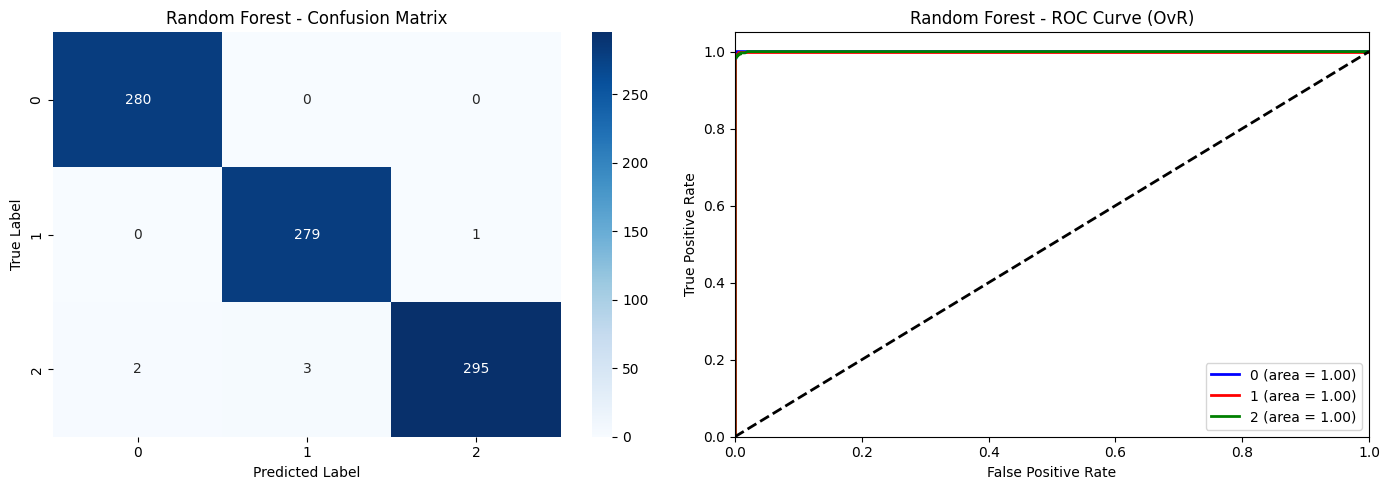


Model: Support Vector Machine
Training Time:  0.7021 s
Prediction Time:0.0487 s

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       280
           1       0.87      1.00      0.93       280
           2       1.00      0.83      0.91       300

    accuracy                           0.94       860
   macro avg       0.94      0.94      0.94       860
weighted avg       0.95      0.94      0.94       860



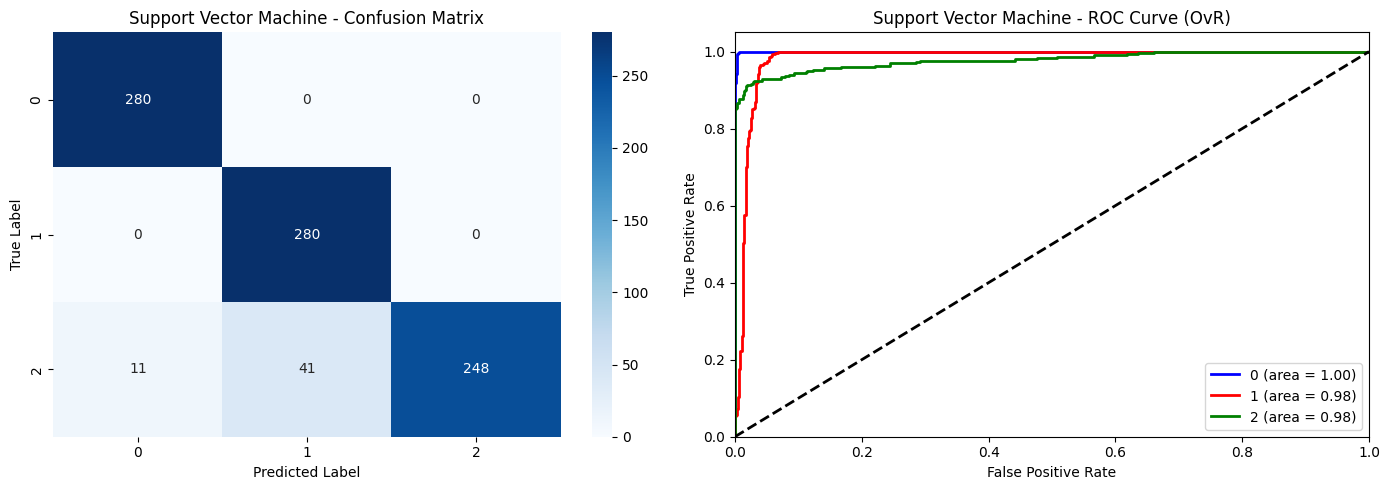


FINAL PERFORMANCE SUMMARY
                 Model  Accuracy   Recall  F1-Score  AUC Score  Train Time (s)  Test Time (s)
               XGBoost  0.994186 0.994186  0.994175   0.999949        1.306804       0.026909
         Random Forest  0.993023 0.993023  0.993012   0.999931        4.486847       0.027723
Support Vector Machine  0.939535 0.939535  0.938415   0.986812        0.702125       0.048653


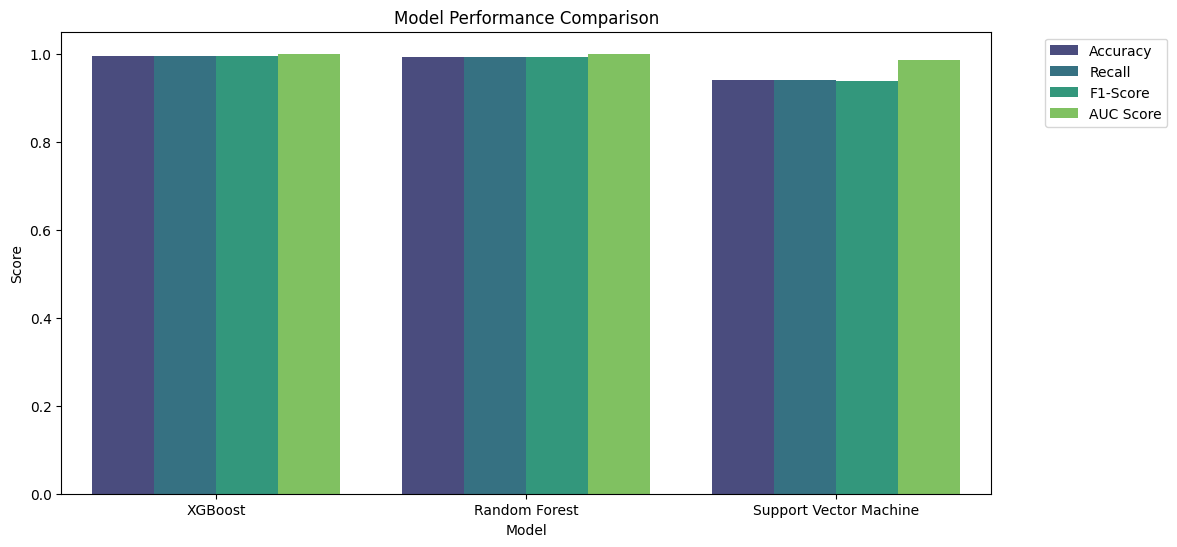

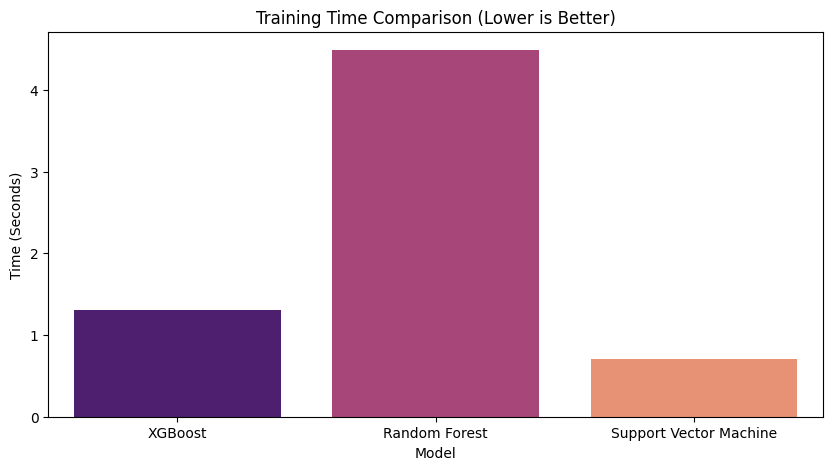

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier  # Make sure to run: pip install xgboost
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc,
                             accuracy_score, roc_auc_score, f1_score, recall_score)
from itertools import cycle

# --- PRE-PROCESSING FOR XGBOOST ---
# XGBoost requires target labels to be integers (0, 1, 2...)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Map back to original class names for plotting
classes = le.classes_
n_classes = len(classes)

# Binarize labels for ROC (One-vs-Rest strategy)
y_test_bin = label_binarize(y_test_enc, classes=range(n_classes))

# --- 1. DEFINE MODELS ---
models = {
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel='rbf', probability=True, decision_function_shape='ovr', random_state=42)
}

model_performance = []

# --- 2. TRAINING & EVALUATION LOOP ---
for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(f"{'='*60}")

    # --- A. Training Time ---
    start_train = time.time()
    model.fit(X_train, y_train_enc) # Use encoded targets
    end_train = time.time()
    train_time = end_train - start_train

    # --- B. Testing Time ---
    start_test = time.time()
    y_pred_enc = model.predict(X_test)
    end_test = time.time()
    test_time = end_test - start_test

    # Get probabilities for ROC
    y_prob = model.predict_proba(X_test)

    # --- C. Calculate Metrics ---
    # Convert predictions back to labels if needed, but metrics calculate fine on encoded integers
    acc = accuracy_score(y_test_enc, y_pred_enc)
    f1 = f1_score(y_test_enc, y_pred_enc, average='weighted')
    recall = recall_score(y_test_enc, y_pred_enc, average='weighted')

    try:
        roc_auc_weighted = roc_auc_score(y_test_enc, y_prob, multi_class='ovr', average='weighted')
    except ValueError:
        roc_auc_weighted = 0
        print("Warning: Could not calculate AUC.")

    # Store results
    model_performance.append({
        "Model": name,
        "Accuracy": acc,
        "Recall": recall,
        "F1-Score": f1,
        "AUC Score": roc_auc_weighted,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    })

    # Print Report
    print(f"Training Time:  {train_time:.4f} s")
    print(f"Prediction Time:{test_time:.4f} s")
    print("\n--- Classification Report ---")
    print(classification_report(y_test_enc, y_pred_enc, target_names=[str(c) for c in classes]))

    # --- D. Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Confusion Matrix
    cm = confusion_matrix(y_test_enc, y_pred_enc)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'{name} - Confusion Matrix')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')
    axes[0].set_xticklabels(classes)
    axes[0].set_yticklabels(classes)

    # 2. ROC Curve (One-vs-Rest)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
    for i, color in zip(range(n_classes), colors):
        axes[1].plot(fpr[i], tpr[i], color=color, lw=2,
                     label=f'{classes[i]} (area = {roc_auc[i]:.2f})')

    axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name} - ROC Curve (OvR)')
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# --- 3. FINAL SUMMARY ---
print(f"\n{'='*60}")
print("FINAL PERFORMANCE SUMMARY")
print(f"{'='*60}")
results_df = pd.DataFrame(model_performance)

# Display sorted by AUC
print(results_df.sort_values(by="AUC Score", ascending=False).to_string(index=False))

# --- 4. COMPARISON PLOTS ---
# Performance Metrics
df_melted = results_df.melt(id_vars="Model",
                            value_vars=["Accuracy", "Recall", "F1-Score", "AUC Score"],
                            var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="viridis")
plt.title("Model Performance Comparison")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

# Time Metrics
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="Train Time (s)", data=results_df, palette="magma")
plt.title("Training Time Comparison (Lower is Better)")
plt.ylabel("Time (Seconds)")
plt.show()

# **Section 6: Hyperparameter Optimization with Grid Search**

## **Minimize Log-Loss**

STARTING HYPERPARAMETER TUNING (Grid Search)
Goal: Minimize Log-Loss (answering RQ3)

Processing: Random Forest...
  -> Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  -> Log-Loss Improvement: 0.00%

Processing: XGBoost...
  -> Best Params: {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 200}
  -> Log-Loss Improvement: 26.78%

Processing: SVM...
  -> Best Params: {'C': 10, 'kernel': 'rbf'}
  -> Log-Loss Improvement: 12.28%

RQ3 FINDINGS: Does Tuning Reduce Error Rate (Log-Loss)?
        Model  Default Log-Loss  Tuned Log-Loss  Log-Loss Reduction (%)  Tuned Accuracy                                                  Best Parameters
Random Forest          0.036157        0.036157                0.000000        0.993023 {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
      XGBoost          0.022457        0.016444               26.776831        0.996512     {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 200}
          SVM    

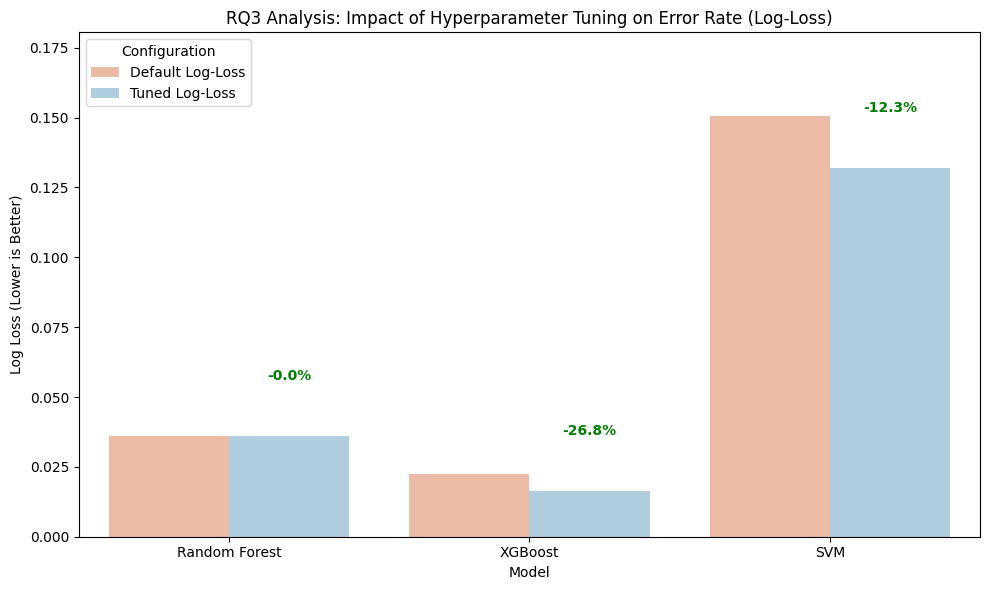

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import log_loss, accuracy_score, f1_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

# --- PRE-PROCESSING ---
# Ensure targets are encoded for XGBoost and Log Loss calculation
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# --- 1. SETUP MODELS & PARAMETER GRIDS ---
# We define the Default model and the Grid of parameters to search
model_configs = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        "params": {
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 6, 10],
            'n_estimators': [100, 200]
        }
    },
    "SVM": {
        # probability=True is REQUIRED for log_loss
        "model": SVC(probability=True, random_state=42),
        "params": {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear']
        }
    }
}

results_data = []

print(f"{'='*60}")
print("STARTING HYPERPARAMETER TUNING (Grid Search)")
print(f"Goal: Minimize Log-Loss (answering RQ3)")
print(f"{'='*60}")

for name, config in model_configs.items():
    print(f"\nProcessing: {name}...")

    # --- A. Baseline (Default Parameters) ---
    base_model = config["model"]
    base_model.fit(X_train, y_train_enc)

    # Predict Probabilities (Critical for Log Loss)
    y_prob_base = base_model.predict_proba(X_test)
    y_pred_base = base_model.predict(X_test)

    # Calculate Baseline Metrics
    base_log_loss = log_loss(y_test_enc, y_prob_base)
    base_acc = accuracy_score(y_test_enc, y_pred_base)

    # --- B. Hyperparameter Tuning (Grid Search) ---
    # We use scoring='neg_log_loss' to specifically optimize for your RQ
    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=3,                 # 3-Fold Cross Validation
        scoring='neg_log_loss',
        n_jobs=-1,            # Use all processors
        verbose=0
    )

    grid_search.fit(X_train, y_train_enc)

    # Get Best Model
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    # --- C. Tuned Evaluation ---
    y_prob_tuned = best_model.predict_proba(X_test)
    y_pred_tuned = best_model.predict(X_test)

    # Calculate Tuned Metrics
    tuned_log_loss = log_loss(y_test_enc, y_prob_tuned)
    tuned_acc = accuracy_score(y_test_enc, y_pred_tuned)

    # Calculate Improvement
    loss_reduction = base_log_loss - tuned_log_loss
    loss_improvement_pct = (loss_reduction / base_log_loss) * 100

    # Store Data
    results_data.append({
        "Model": name,
        "Default Log-Loss": base_log_loss,
        "Tuned Log-Loss": tuned_log_loss,
        "Log-Loss Reduction (%)": loss_improvement_pct,
        "Default Accuracy": base_acc,
        "Tuned Accuracy": tuned_acc,
        "Best Parameters": str(best_params)
    })

    print(f"  -> Best Params: {best_params}")
    print(f"  -> Log-Loss Improvement: {loss_improvement_pct:.2f}%")

# --- 2. SUMMARIZED EVALUATION TABLE ---
results_df = pd.DataFrame(results_data)

print(f"\n{'='*80}")
print("RQ3 FINDINGS: Does Tuning Reduce Error Rate (Log-Loss)?")
print(f"{'='*80}")
# Reorder columns for clarity
cols = ["Model", "Default Log-Loss", "Tuned Log-Loss", "Log-Loss Reduction (%)", "Tuned Accuracy", "Best Parameters"]
print(results_df[cols].to_string(index=False))

# --- 3. VISUALIZATION FOR RQ3 ---
plt.figure(figsize=(10, 6))

# Prepare data for plotting
plot_data = results_df.melt(id_vars="Model",
                            value_vars=["Default Log-Loss", "Tuned Log-Loss"],
                            var_name="Configuration", value_name="Log Loss")

# Bar Plot
sns.barplot(x="Model", y="Log Loss", hue="Configuration", data=plot_data, palette="RdBu")

plt.title("RQ3 Analysis: Impact of Hyperparameter Tuning on Error Rate (Log-Loss)")
plt.ylabel("Log Loss (Lower is Better)")
plt.ylim(0, max(results_df["Default Log-Loss"]) * 1.2) # Add some headroom
plt.legend(title="Configuration")

# Annotate the improvement percentage on the chart
for i, row in results_df.iterrows():
    # Place text above the 'Tuned' bar
    plt.text(i + 0.2, row["Tuned Log-Loss"] + 0.02,
             f"-{row['Log-Loss Reduction (%)']:.1f}%",
             color='green', weight='bold', ha='center')

plt.tight_layout()
plt.show()

# **Section 7: K-Fold Cross Validation**

10-FOLD CROSS-VALIDATION RESULTS
XGBoost: Accuracy = 0.9921 (+/- 0.0044)
Random Forest: Accuracy = 0.9965 (+/- 0.0030)
SVM: Accuracy = 0.6219 (+/- 0.0214)

SUMMARY TABLE
        Model  Mean Accuracy  Standard Deviation  Min Score  Max Score
Random Forest       0.996512            0.002987   0.990698   1.000000
      XGBoost       0.992093            0.004437   0.986047   1.000000
          SVM       0.621860            0.021370   0.581395   0.651163


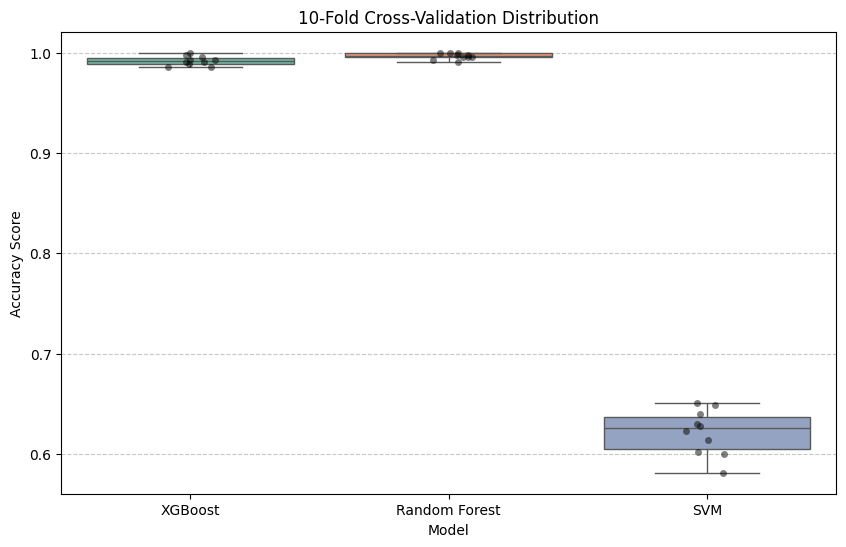

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# 1. Define Models
models = {
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42)
}

# 2. Configure Stratified K-Fold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results_cv = []
results_plot = []

print(f"{'='*60}")
print("10-FOLD CROSS-VALIDATION RESULTS")
print(f"{'='*60}")

for name, model in models.items():
    # Run Cross-Validation
    # Assuming X and y are already preprocessed (encoded/scaled)
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

    # Calculate Mean and Std Dev
    mean_score = scores.mean()
    std_dev = scores.std()

    print(f"{name}: Accuracy = {mean_score:.4f} (+/- {std_dev:.4f})")

    # Store for Summary Table
    results_cv.append({
        "Model": name,
        "Mean Accuracy": mean_score,
        "Standard Deviation": std_dev,
        "Min Score": scores.min(),
        "Max Score": scores.max()
    })

    # Store for Boxplot
    for score in scores:
        results_plot.append({"Model": name, "Accuracy": score})

# --- 3. SUMMARY TABLE ---
results_df = pd.DataFrame(results_cv)
results_df = results_df.sort_values(by="Mean Accuracy", ascending=False)

print(f"\n{'='*60}")
print("SUMMARY TABLE")
print(f"{'='*60}")
print(results_df.to_string(index=False))

# --- 4. VISUALIZATION (BOXPLOT) ---
plt.figure(figsize=(10, 6))
sns.boxplot(x="Model", y="Accuracy", data=pd.DataFrame(results_plot), palette="Set2")
sns.stripplot(x="Model", y="Accuracy", data=pd.DataFrame(results_plot),
              color='black', alpha=0.5, jitter=True)

plt.title("10-Fold Cross-Validation Distribution")
plt.ylabel("Accuracy Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()